# Day 25

PyTorch and Tensorflow are large deep learning libraries. They do all the heavy computation in regards to training neural networks.

Here, PyTorch records the mathematical operations used during the forward pass and can then automatically calculate the required gradients during th backward pass.

#### Keras

This is a deep learning API, and it is basically Scikit-Learn for deep neural networks. You can do most of the things in tensorflow, but keras will make our life easier

--- 

### Photo-z with deep learning

We can build a deep neural network that is trained on a sample of SDSS color data, allowing us to use observed galaxy colour data to estimate the redshift.



In [20]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as torchdata

from astroML.datasets import fetch_sdss_specgals
from astroML.utils.decorators import pickle_results

from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

Let us read in and prepare the SDSS data:


In [21]:
# Fetch and prepare the data
data = fetch_sdss_specgals()

# put magnitudes into array
# normalize to zero mean and unit variance for easier training
datanormed = np.zeros((len(data), 6), 
                      dtype=np.float32)
for i, band in enumerate(['u', 'g', 'r', 'i', 'z']):
    band = 'modelMag_' + band
    datanormed[:, i] = ((data[band] - data[band].mean()) / 
                        data[band].std())

# put redshifts into array
datanormed[:, 5] = data['z']

Let's make a helper class that will make our network. 

In [22]:
# define structure of neural net
class Net(nn.Module): # Defining the pytorch neural network model
    def __init__(self, nhidden):
        super(Net, self).__init__()
        self.fc_h = nn.Linear(5, nhidden) # This means 5 input features to nhidden amounts of hidden neurons
        self.fc_o = nn.Linear(nhidden, 1) # Take the hidden features and produce 1 value

    def forward(self, x): # This is forward propagation
        h = F.relu(self.fc_h(x))
        z = self.fc_o(h) # No activation function as we want something linear
        return z

This is a network with 5 inputs, one hidden layers, we can choose the number of hidden neurons, it uses ReLU activation and it returns 1 output.

Mathematically, nn.Linear performs:

$$
Z_h=XW_h+b_h
$$


In [23]:
# split data into 9:1 train:test
dataset = torchdata.TensorDataset(torch.tensor(datanormed[:, 0:5]),
                                  torch.tensor(datanormed[:, 5]).view(-1, 1))
trainnum = datanormed.shape[0] // 10 * 9
traindata, testdata = torchdata.random_split(dataset, 
                                             [trainnum, datanormed.shape[0] - trainnum])
traindataloader = torchdata.DataLoader(traindata, 
                                       batch_size=128, 
                                       shuffle=True)

The first tensor contains all our features $X: (N,5)$ and the second one has our targets $y: (N,1)$. 

.view(-1,1) makes it into a 1 column array instead of (N,)

We can see that a training and test split are created.

The dataloader uses mini batches to select 128 training data to calculate the gradient for. The batches are shuffled so that each epoch presents the data in a different order.

> The distinction between epoch are like sets and reps, within this the batch size is 1 group (128) but an epoch is a complete pass through the entire training dataset, requiring 100 gradient updates during one epoch as $\frac{12800}{128} = 100$




In [24]:
@pickle_results('NNphotoz.pkl')
def train_NN():
    # 4 hidden neurons
    model = Net(4)
    # MSE loss
    criterion = torch.nn.MSELoss(reduction='sum') 
    # stochastic gradient descent optimiser
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001) 
    # Adaptive learning rate...
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                           patience=5, 
                                                           threshold=1e-3)

    min_valid_loss = float('inf')
    badepochs = 0
    for t in range(50):
        train_loss = 0
        for i, databatch in enumerate(traindataloader, 0):
            photometry, redshifts = databatch
            optimizer.zero_grad() # Initalize optimizer and clears gradients calculated during previous batch
            z_pred = model(photometry) # Predictions
            loss = criterion(z_pred, redshifts) # Compute loss
            loss.backward() # Backpropagation 
            optimizer.step() # Step in gradient descent
            train_loss += loss.item() # Update loss

        with torch.no_grad():
            photometry = testdata[:][0]
            redshifts = testdata[:][1]
            z_pred = model(photometry)
            valid_loss = criterion(z_pred, redshifts)
            if t % 10 == 0:
                print('Epoch %3i: train loss %0.3e validation loss %0.3e' % (t, \
                        train_loss / len(traindata), valid_loss / len(testdata)))
            # stop training if validation loss has not fallen in 10 epochs
            if valid_loss > min_valid_loss*(1-1e-3):
                badepochs += 1
            else:
                min_valid_loss = valid_loss
                badepochs = 0
            if badepochs == 10:
                print('Finished training')
                break
        scheduler.step(valid_loss)
    return model

In [25]:
model = train_NN()

@pickle_results: using precomputed results from 'NNphotoz.pkl'


Now we should plot the results:

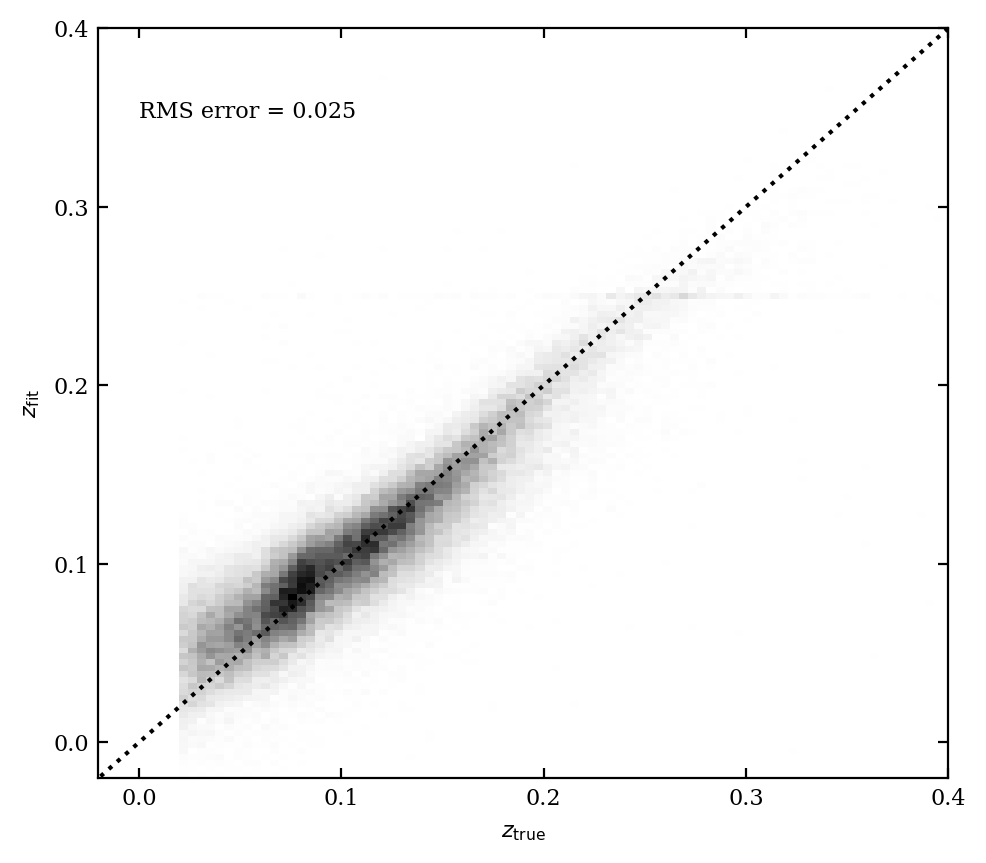

In [26]:
# plot the results
with torch.no_grad():
    photometry = testdata[:][0]
    redshifts = testdata[:][1]
    z_pred = model(photometry)
    fig = plt.figure(figsize=(5, 5))
    fig.subplots_adjust(wspace=0.25,
                        left=0.1, right=0.95,
                        bottom=0.15, top=0.9)

    ax = plt.axes()
    H, zs_bins, zp_bins = np.histogram2d(redshifts.numpy().flatten(), 
                                         z_pred.numpy().flatten(), 151)
    ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
               extent=[zs_bins[0], zs_bins[-1], zp_bins[0], zp_bins[-1]],
               cmap=plt.cm.binary)
    ax.plot([-0.1, 0.4], [-0.1, 0.4], ':k')
    rms = np.sqrt(np.mean((z_pred-redshifts).numpy()**2))
    
    ax.text(0, 0.35, 'RMS error = %0.3f' % np.sqrt(np.mean((z_pred-
                                                            redshifts).numpy()**2)))
    ax.set_xlim(-0.02, 0.4001)
    ax.set_ylim(-0.02, 0.4001)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    
    ax.set_xlabel(r'$z_{\rm true}$')
    ax.set_ylabel(r'$z_{\rm fit}$')
    
    plt.show()

This is pretty good!

### CNNs

If we apply standard perceptron to images, it will look at each pixel independently, which doesn't account for the useful concept that the nearby pixels are correlated.
> A perceptron is the simplest possible artificial neuron used as a binary classifier

These are inspired by our visual perception. Individual neurons respond to local regions instead of the entire field of vision. Different neurons can also respond to different patterns such as horizontal vs vertical structure.

They use convolution and pooling to exploit the spatial structure and reduce dimensionality.

#### Convolution Layer 

In this layer, each neuron is not connected to the neurons in the previous layer, but only those that it "sees" as defined by a kernel (filter). We slide the kernel over the input layer and the value in the next layer depends only on those pixels

We use the convolution layer to capture high level features in the images, like edges, kind of like polarising light.

For example, we could have a kernel (this is a small matrix of weights) where:

$$
K=
\begin{pmatrix}
-1&0&1\\
-1&0&1\\
-1&0&1
\end{pmatrix}
$$

And this pattern responds strongly to changes from left to right so it could be used to detect vertical edges, maybe.


#### Pooling layer

Pooling commonly follows convolution and reduces how much data needs to be processed, and a full architecture of a CNN may look something like:

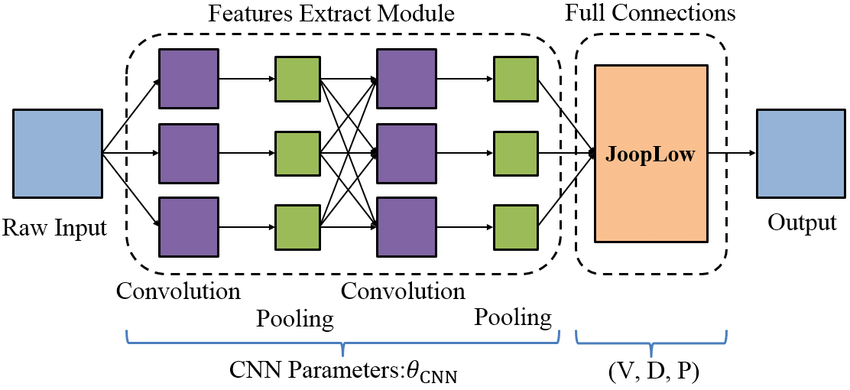

Where the pooling layers are reducing the number of pixels by averaging, summing, taking the max, etc.

**Max Pool** is the most popular and it corresponds to taking the maximum of the convolution




In [27]:
from tensorflow import keras

fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print(X_train_full.shape)
print(X_test.shape)

X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(55000, 28, 28)
(5000, 28, 28)
(10000, 28, 28)


This dataset has a large collection of images of items of clothing, we can see that we have 60000 images, 28 pixels high and wide. And since we have 784 different pixels, they are related in a way where we can use CNN's

This code takes the first 5000 images for validation and the rest for training, but the pixel values are also scaled

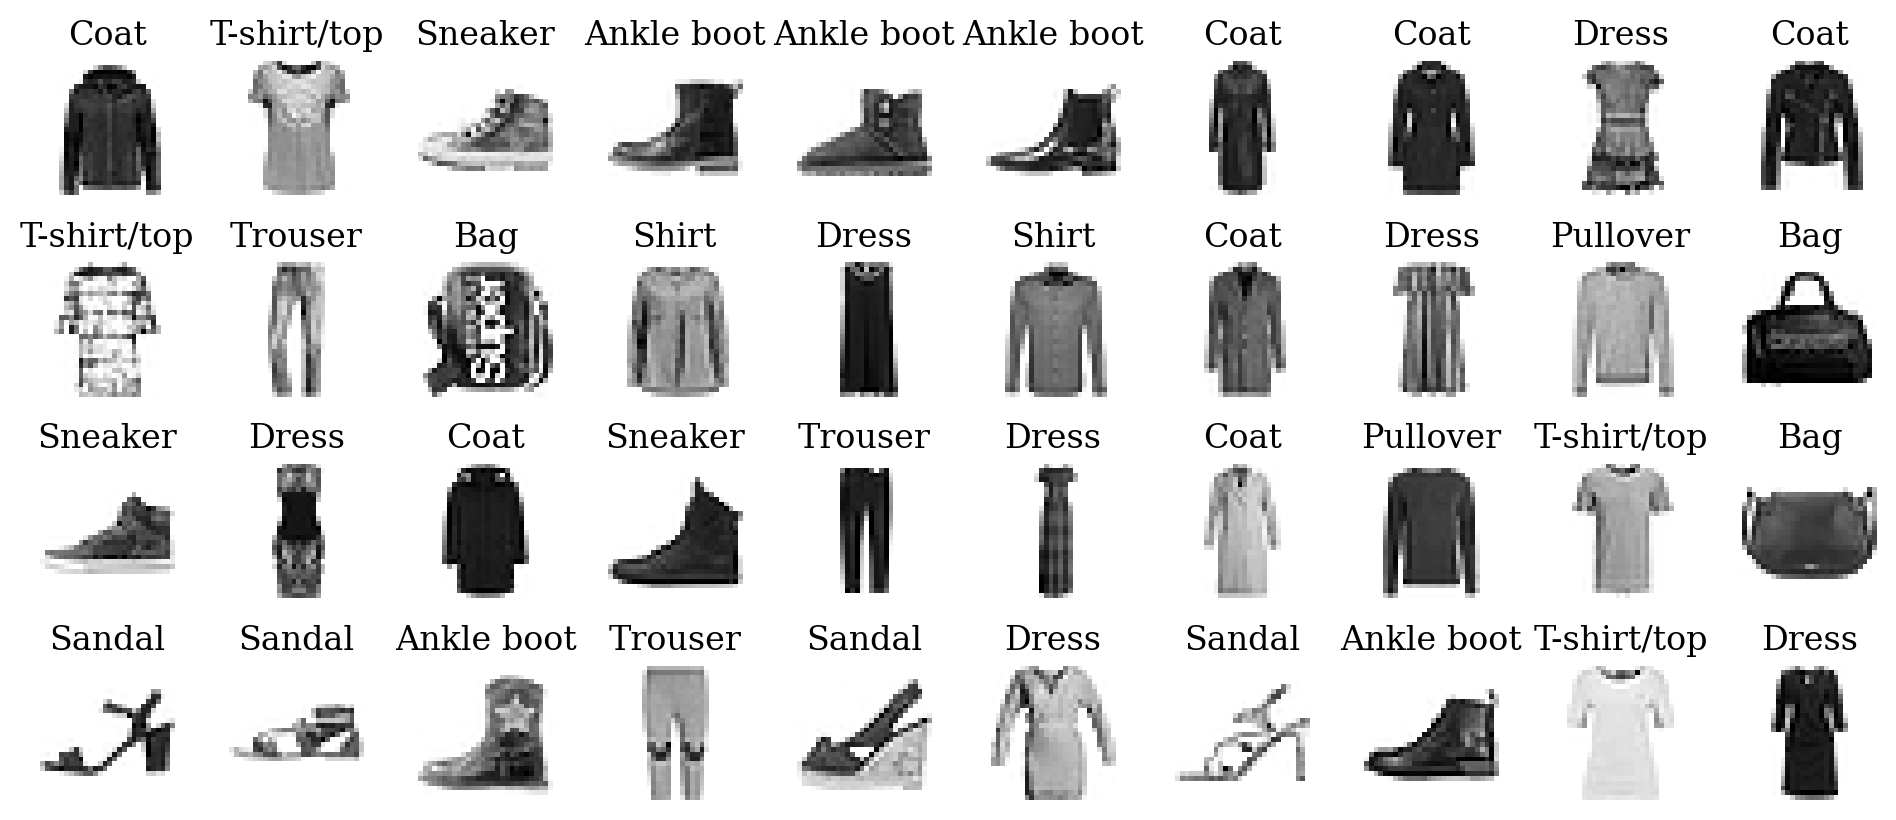

In [28]:
# Let's make a list of class names that we can refer to.
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Plot 4x10 array of images from the Fashion MNIST database
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest", origin='upper')
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Looped over a $4 \times 10$ grid to form the images, we can see that each image has pixels that are correlated to each other.

In [29]:
import tensorflow as tf

keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)

We are using tensorflow on the data set, and because we want to preserve the contextual information  like the edges of the images, we will build a CNN.

Clearing the session ensures we are starting a new model

In [30]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std


# Need to reshape for CNN
X_train = X_train[:, :, :, np.newaxis]
X_valid = X_valid[:,  :, :, np.newaxis]
X_test = X_test[:, :, :, np.newaxis]

print(len(X_train))
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

55000
(55000, 28, 28, 1)
(5000, 28, 28, 1)
(10000, 28, 28, 1)


We are just normalising the data using:
$$
X'
=
\frac{X-\mu_{\rm train}}
{\sigma_{\rm train}}
$$

We are only using the training data's mean and standard deviation. And we add $10^-7$ for a safeguarding against a pixel that is located at 0 standard deviation for example.

In [31]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[28, 28, 1]),
    keras.layers.Conv2D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),  
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(256, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(256, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

This is a combination of 2D convolution, Max Pooling, into Dense and then Dropout



In [32]:

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

None


We are basically learning spacial features, then classifying using those learned features.

In [33]:
#### This may take a while! Hopefully no more than 5 minutes for 1 epoch.
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=1, validation_data=(X_valid, y_valid))

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.7655 - loss: 0.6762 - val_accuracy: 0.8628 - val_loss: 0.3751


We only use 1 epoch as otherwise we may be here for a while, luckily it only took me 37 seconds.

So what are we looking at here,

1. **loss = sparse categorical crossentropy**

$$
J=-\log p_y
$$

If the network gives a class probability for a prediction, it will calculate the relevant loss. A smaller value of $p_y$ relates to a large penalty as the prediction would be confidently incorrect.

2. Nadam optimiser

This works like we previously had with the following pipeline:

$$
J
\xrightarrow{\text{backprop}}
\nabla_\theta J
\xrightarrow{\text{Nadam}}
\theta_{\rm new}
$$

#### Training results

We can see our results as:

$$
\text{training accuracy}=0.7413
$$

$$
\text{validation accuracy}=0.8630
$$

And

$$
J_{\rm train}=0.7366,
\qquad
J_{\rm valid}=0.3805
$$

This implies that the validation performance is already at 86%

We can then use these to predict things:

In [34]:
X_new = X_test[:3]
y_proba = model.predict(X_new).round(2)
print(y_proba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.   0.   0.   0.   0.   0.   0.   0.01 0.   0.99]
 [0.   0.   0.99 0.   0.   0.   0.01 0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]


This is saying that image 1 has a 70% chance of being an ankle boot

In [35]:
y_pred = np.argmax(
    model.predict(X_new),
    axis=-1
)

print(y_pred)
print(np.array(class_names)[y_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[9 2 1]
['Ankle boot' 'Pullover' 'Trouser']


We can plot these as well if we would like:

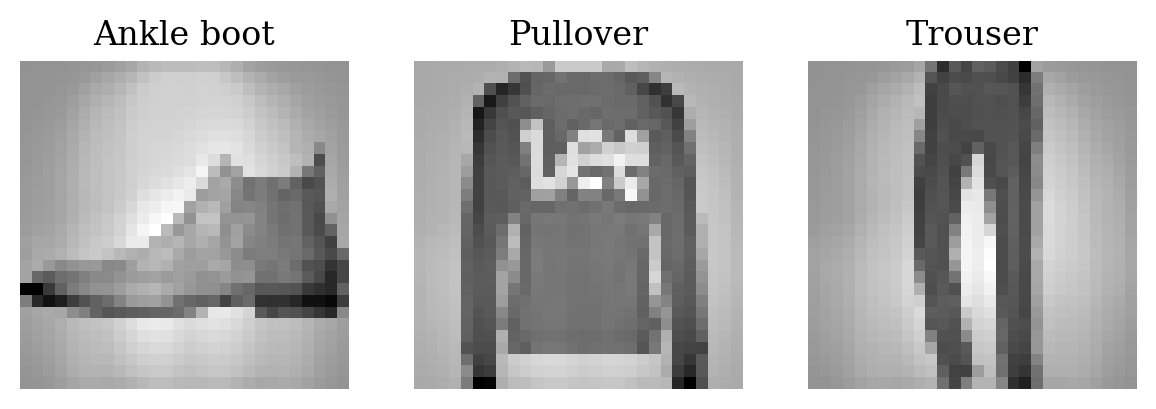

In [36]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest", origin='upper')
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

We also want to be able to save our model:



In [37]:
# Save model
model.save("my_keras_model.h5")

# Reload model
model = keras.models.load_model("my_keras_model.h5")

So we should put our model to the test, lets do this with 10 random objects, print the actual labels and then show the predictions

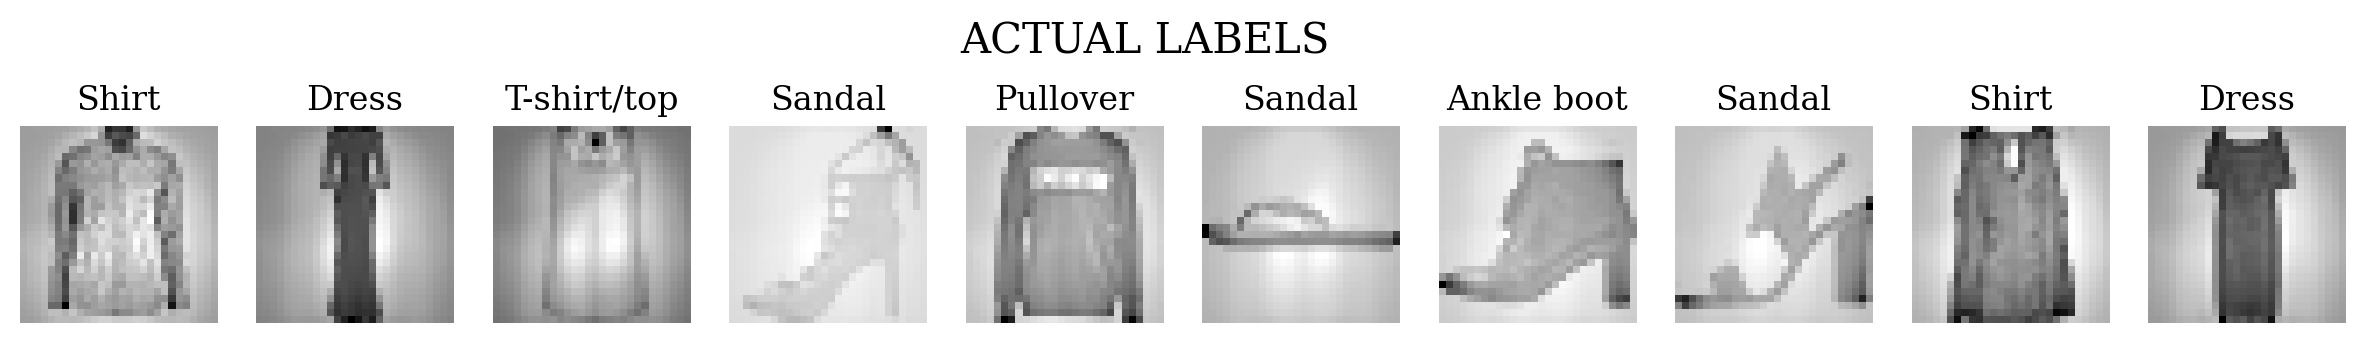

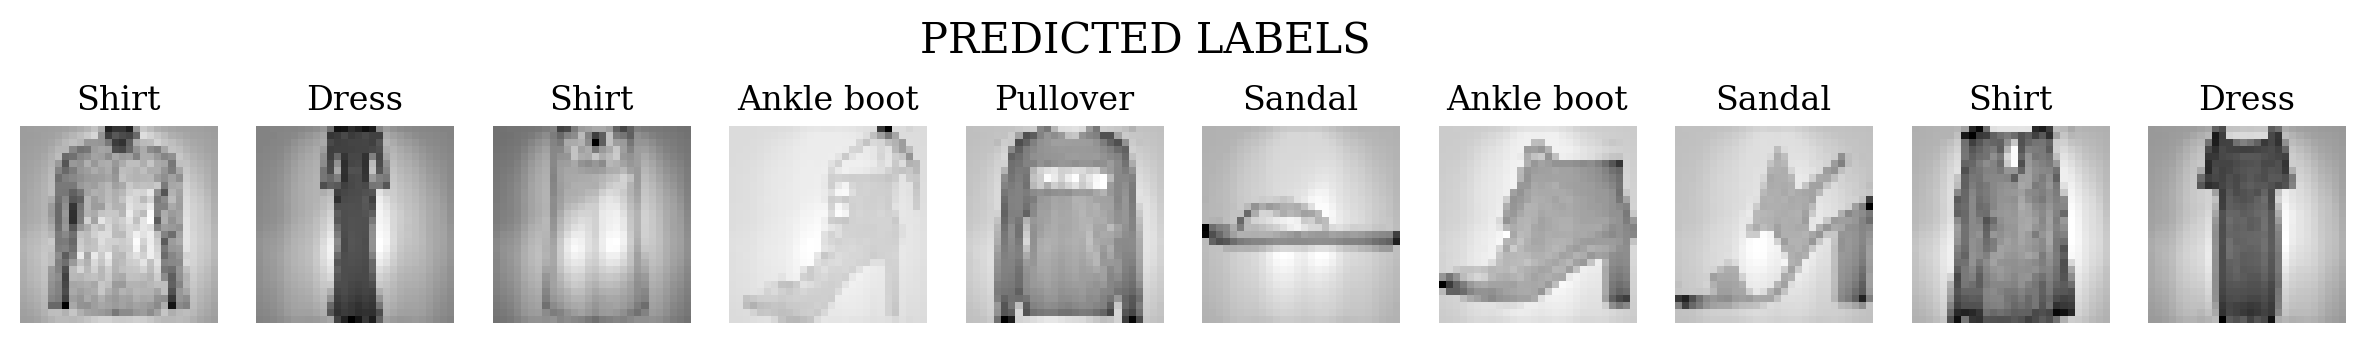

In [39]:
# Pick 10 random test images
idx10 = np.random.choice(
    np.arange(len(y_test)),
    size=10,
    replace=False
)

X_new = X_test[idx10]

# Get model predictions for those same 10 images
y_proba = model.predict(X_new, verbose=0)
y_pred = np.argmax(y_proba, axis=-1)



# Correct answers (y_test)

plt.figure(figsize=(15, 5))

for index, image in enumerate(X_new):

    plt.subplot(1, 10, index + 1)

    plt.imshow(
        image.squeeze(),
        cmap="binary",
        interpolation="nearest",
        origin="upper"
    )

    plt.axis("off")

    plt.title(
        class_names[y_test[idx10[index]]],
        fontsize=12
    )

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.suptitle("ACTUAL LABELS", y=0.7, fontsize=15)
plt.show()

# Predicted answers (y_pred)
plt.figure(figsize=(15, 5))

for index, image in enumerate(X_new):

    plt.subplot(1, 10, index + 1)

    plt.imshow(
        image.squeeze(),
        cmap="binary",
        interpolation="nearest",
        origin="upper"
    )

    plt.axis("off")

    plt.title(
        class_names[y_pred[index]],
        fontsize=12
    )

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.suptitle("PREDICTED LABELS", y=0.7, fontsize=15)
plt.show()

Remember this was trained on 1 epoch so not too bad

### Autoencoders

Autoencoders are neural networks that copy their input to their output, but after passing the data through a compression bottleneck.

So if there are 784 inputs, there will also be 784 outputs. However, the hidden layers usually contain fewer neurons.

Hence, we go from the original data to a compressed representation and then back to a reconstruction of the original data.

We can split this set up into 2 halves:

$$
X
\xrightarrow{\text{encoder}}
z
\xrightarrow{\text{decoder}}
\hat X
$$

Where quite simply the encoder compresses the data, and the decoder attempts to reconstruct the original data from that compression.

We mentioned a compression bottleneck, and following:

$$
784
\rightarrow
128
\rightarrow
32
\rightarrow
128
\rightarrow
784
$$

We see that the central 32 is the bottleneck This is because the network needs to somehow describe the 784 numbers using only 32 numbers. So it has to learn which combination of information actually matters.

This is the deep learning problem of dimensionality reduction. So we can think of an autoencoder as doing PCA with a neural network; breaking our data down into only the most important features that we need.

### Variational Autoencoders

The latent space produced by an autoencoder does not necessarily map continuously onto the data space. Meaning that the decoder may not know how to interpet certain points such as (0,0). This can happen if your training data doesn't represent the possibilities or span of the full data set

> The latest space is the compressed representation of the data

So how does a variational autoencoder work? It encodes an object as a continuous probability distribution, this encoded representation has a mean and variance. Where the mean centres the encoding while the variance describes the spread around the centre. This allows for smoother interpolation across the data.

$$
X
\rightarrow
\mu,\sigma^2
\rightarrow
z\sim\mathcal N(\mu,\sigma^2)
$$

So instead of saying a certain galaxy lies at a latent coordinate (1.3,-0.7). The encoder says that the galaxy lies around (1.3,-0.7) with some spread around the location. 

We can look at an example on SDSS data using PyTorch:

In [40]:
from astroML.datasets import sdss_corrected_spectra
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

# Fetch and prepare the data
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)

# normalize spectra by integrated flux and subtract out mean, for easier training
spectranorms = np.mean(spectra, axis=1)
normedspectra = spectra / spectranorms[:, None]
meanspectrum = np.mean(normedspectra, axis=0)
normedspectra -= meanspectrum[None, :]

# split data into 3:1 train:test
torch.manual_seed(802)  # seed used for book figure
dataset = torchdata.TensorDataset(torch.tensor(normedspectra))
trainnum = normedspectra.shape[0] // 4 * 3
traindata, testdata = torchdata.random_split(dataset, 
                                             [trainnum, normedspectra.shape[0] - trainnum])
traindataloader = torchdata.DataLoader(traindata, batch_size=128, shuffle=True)

Now after this code, we will reduce the 1000 dimension input down to 250

Then we shall use those features to describe a 2D latent probability distribution

Finally we want to sample from the 2D distribution and expand the result back into a 1000 dimensional reconstructed spectrum

In [41]:
# define structure of variation autoencoder
class VAE(nn.Module):
    def __init__(self, nhidden=250):
        super(VAE, self).__init__()

        # encoding layers
        self.encode_fc = nn.Linear(1000, nhidden)
        self.mu        = nn.Linear(nhidden, 2)
        self.logvar    = nn.Linear(nhidden, 2)

        # decoding layers
        self.decode_fc = nn.Linear(2, nhidden)
        self.output    = nn.Linear(nhidden, 1000)

    def encode(self, x):
        h = F.relu(self.encode_fc(x))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu)

    def decode(self, z):
        h = F.relu(self.decode_fc(z))
        return self.output(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

The loss is a modified MSE that also included a Kullback Leilber divergence which also checks how close the latent distribution is to a gaussian

In [42]:
# add KL divergence to loss function
def VAEloss(criterion, recon_x, x, mu, logvar):
    return criterion(recon_x, x) - 0.5 * torch.sum(1 + logvar - 
                                                   mu.pow(2) - 
                                                   logvar.exp())

Then we want to train the network... Lots of codeee

In [45]:
def train_model():
    model = VAE()
    criterion = torch.nn.MSELoss(reduction='sum')
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                           patience=5, 
                                                           threshold=1e-3)

    min_valid_loss = float('inf')
    badepochs = 0
    for t in range(1000):
        train_loss = 0
        for i, databatch in enumerate(traindataloader, 0):
            specbatch = databatch[0]
            optimizer.zero_grad()
            recon, mu, logvar = model(specbatch)
            loss = VAEloss(criterion, recon, 
                           specbatch, mu, logvar)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        with torch.no_grad():
            testspec = testdata[:][0]
            recon, mu, logvar = model(testspec)
            valid_loss = VAEloss(criterion, recon, 
                                 testspec, mu, logvar)
            if t % 10 == 0:
                print('Epoch %3i: train loss %6.1f validation loss %6.1f' % \
                        (t, train_loss / len(traindata), valid_loss / len(testdata)))
            # stop training if validation loss has not fallen in 10 epochs
            if valid_loss > min_valid_loss*(1-1e-3):
                badepochs += 1
            else:
                min_valid_loss = valid_loss
                badepochs = 0
            if badepochs == 10:
                print('Finished training')
                break
        scheduler.step(valid_loss)
    return model

In [46]:
model = train_model()

Epoch   0: train loss 2282.0 validation loss 1264.4
Epoch  10: train loss  555.3 validation loss  491.5
Epoch  20: train loss  283.2 validation loss  335.7
Epoch  30: train loss  197.5 validation loss  279.2
Epoch  40: train loss  157.0 validation loss  263.3
Epoch  50: train loss  155.9 validation loss  250.0
Epoch  60: train loss  115.5 validation loss  240.2
Epoch  70: train loss  103.5 validation loss  229.6
Epoch  80: train loss  104.8 validation loss  225.1
Epoch  90: train loss   92.1 validation loss  222.8
Epoch 100: train loss   91.3 validation loss  222.6
Finished training


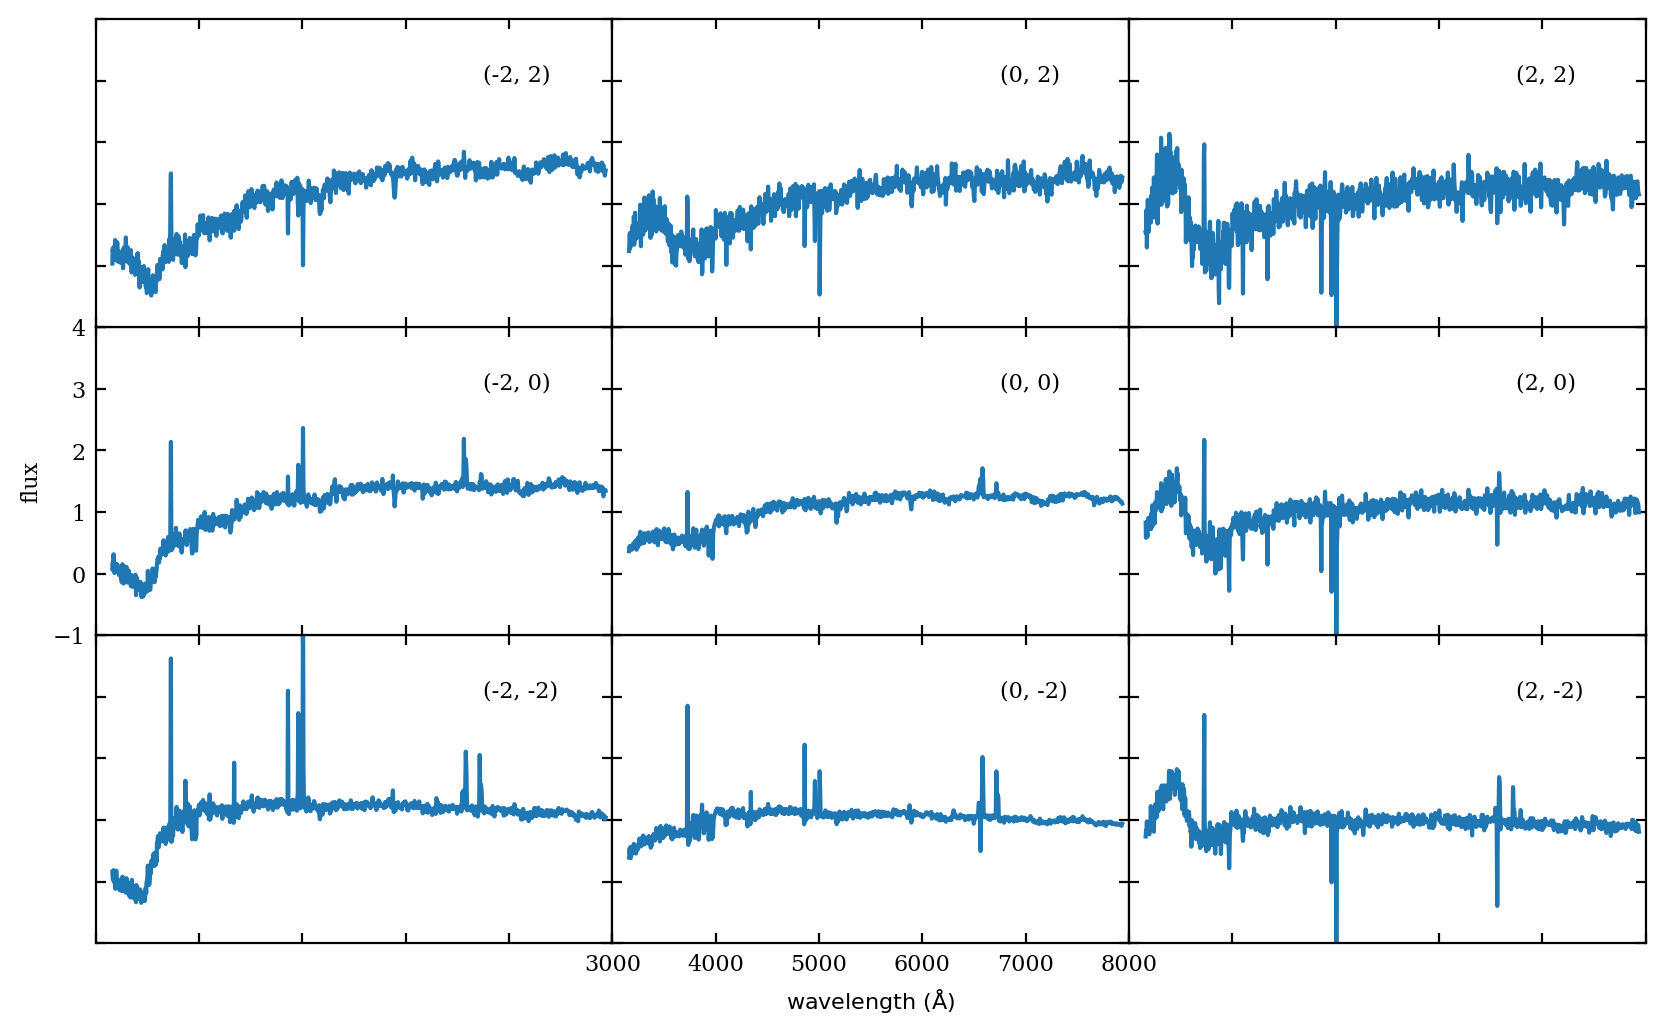

In [47]:
# plot results
with torch.no_grad():
    # sort latent parameters from most constrained to least constrained
    testspec = dataset[:][0]
    recon, mu, logvar = model(testspec)
    zorder = np.argsort(np.mean(logvar.numpy(), axis=0))

    fig = plt.figure(figsize=(10, 6))
    fig.subplots_adjust(hspace=0, wspace=0)
    parvalues = [-2.,0.,2.]
    for i, z1 in enumerate(parvalues):
        for j, z2 in enumerate(parvalues):
            # get z1 to vary left to right, z2 bottom to top
            ax = fig.add_subplot(3, 3, (2-j)*len(parvalues)+i+1)

            z = np.zeros((1,2), dtype=np.float32)
            z[0, zorder] = z1, z2 # set z1 is more constrained of the two latent parameters
            spectrum = model.decode(torch.tensor(z))
            ax.plot(wavelengths, meanspectrum+spectrum.numpy()[0,:])
            ax.text(6750, 3, '(%i, %i)' % (z1,z2))

            ax.set_xlim(3000, 8000)
            ax.set_ylim(-1, 4)

            if i == 0 and j == 1:
                ax.set_ylabel('flux')
            else:
                ax.yaxis.set_major_formatter(plt.NullFormatter())
            if j == 0 and i == 1:
                ax.set_xlabel(r'${\rm wavelength\ (\AA)}$')
            else:
                ax.xaxis.set_major_formatter(plt.NullFormatter())
plt.show()

Each panel shows a galaxy spectrum generated by the VAE decoder at a different point in the 2d latent space, with coordinates $(z_1,z_2)\in\{-2,0,2\}$. Moving horizontally changes one latent variable, while moving vertically changes the other.

The spectra change smoothly across the grid, showing that nearby points in latent space correspond to similar spectral shapes. Different regions show changes in the shape of the continum and in the strength of emission lines.

The VAE has compressed the original 1000D spectra into only two latent variables while still retaining meaningful structure. Because these spectra are produced by feeding $(z_1,z_2)$ directly into the decoder, they are generated spectra rather than reconstructions of specific galaxies.

### Generative Adversarial Networks (GANs)

This idea builds on autoencoders. 

1. We have a generator (like a decoder within an autoencoder) for fake data (e.g an image)
2. We have a discriminator (standard binary classifier) that tries to distinguish the fake data from the real
3. The generator learns to produce more and more accurate images to trick the discriminator without ever seeing any real images

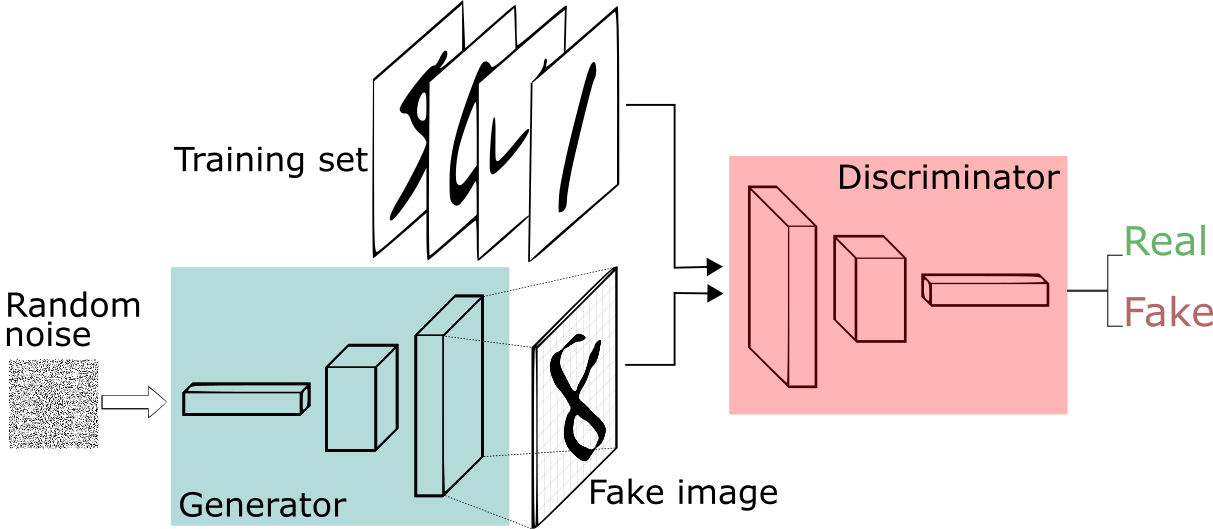

(should check out the uses of these)

### Flows and Simulation based inference (SBI)

MAFs are a deep learning solution to density estimation. (not looked into heavily, I should have a look)

Simulation based inference (likelihood based inference) can be used to obtain the posterior distribution even when we can not write the likelihood analytically

So basically we can generate lots of examples, and train a neural density estimator to learn the relationship between parameters and data. Eventually, given the real observations, we can infer a posterior without having written the likelihood.

This can be useful if we don't know the likelihood due to gaps in knowledge, complicated instrumental behaviour or unmodelled artefacts.